# Visualising Text Embeddings with UMAP

Sentences -> Gemini embedding vectors -> UMAP -> a 2D picture of meaning.

| Step | Function |
|------|----------|
| Embed | `embed(texts)` |
| Reduce | `reduce(vectors)` |
| Plot | `plot(coords, labels)` |

Functions first, then we chain them.

---
## 1. Setup

API key lives in the repo-root `.env` as `GEMINI_API_KEY`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import umap
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv("/home/vishal/Classroom/MTech-NLP/.env")
api_key = os.getenv("GEMINI_API_KEY")

client = genai.Client(api_key=api_key)
MODEL = "gemini-embedding-001"
print("ready")

ready


---
## 2. Embed

`gemini-embedding-001` gives 3072 dims by default; we ask for 768 to keep it light.

`task_type="SEMANTIC_SIMILARITY"` tells the model the vectors are for comparing meaning.

`normalize=True` scales every vector to length 1. Section 9 shows why that matters —
for now, note it is a *flag*, so we can turn it off and see what breaks.

In [2]:
def embed(texts, task_type="SEMANTIC_SIMILARITY", dim=768, normalize=True):
    """Text list -> (n, dim) array. Set normalize=False to see the raw vectors."""
    response = client.models.embed_content(
        model=MODEL,
        contents=texts,
        config=types.EmbedContentConfig(task_type=task_type, output_dimensionality=dim),
    )
    vectors = np.array([e.values for e in response.embeddings], dtype=np.float32)
    if normalize:
        vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors

---
## 3. Data

Four topics with barely overlapping vocabulary, so clusters should separate cleanly.

In [3]:
CORPUS = {
    "sports": [
        "The striker scored a hat-trick in the second half.",
        "She broke the national record in the 200 metre sprint.",
        "The team lost the final on a penalty shootout.",
        "He was substituted after pulling a hamstring.",
        "The umpire declared the batsman out on review.",
        "Their coach resigned after a fifth straight defeat.",
    ],
    "cooking": [
        "Fold the beaten egg whites gently into the batter.",
        "Let the dough rest for an hour before rolling.",
        "Sear the meat on high heat to lock in the juices.",
        "Season the soup with salt and cracked black pepper.",
        "Simmer the sauce until it reduces by half.",
        "Toast the spices before grinding them.",
    ],
    "programming": [
        "The function returns a list of normalised vectors.",
        "We refactored the module to remove a circular import.",
        "The test suite fails because of a deprecation warning.",
        "Use a dictionary for constant time lookups.",
        "The API request timed out after thirty seconds.",
        "Profiling showed the bottleneck was in the inner loop.",
    ],
    "astronomy": [
        "The telescope resolved two stars in a binary system.",
        "Light from the quasar took ten billion years to reach us.",
        "The comet will return to the inner solar system in 2061.",
        "Astronomers detected water vapour in the exoplanet atmosphere.",
        "The nebula is a stellar nursery full of hot young stars.",
        "A supernova briefly outshone its entire host galaxy.",
    ],
}

texts = [t for sentences in CORPUS.values() for t in sentences]
labels = [label for label, sentences in CORPUS.items() for _ in sentences]

print(len(texts), "sentences,", len(CORPUS), "topics")

24 sentences, 4 topics


---
## 4. Reduce

UMAP builds a nearest-neighbour graph in 768-D, then lays that graph out in 2D.

| Parameter | Effect |
|-----------|--------|
| `n_neighbors` | Small = local detail, many fragments. Large = global shape. |
| `min_dist` | How tightly points may pack. |
| `metric="cosine"` | Direction matters, magnitude does not. |
| `random_state` | Same layout every run. |

**Reading the plot:** clusters and neighbourhoods are meaningful. Distances *between*
separated clusters, and the axis numbers, are not.

In [ ]:
def reduce(vectors, n_components=2, n_neighbors=8, min_dist=0.1):
        """(n, dim) -> (n, n_components) coordinates."""
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="cosine",
            random_state=42,
        )
        return reducer.fit_transform(vectors)

---
## 5. Plot

In [5]:
def plot(coords, labels, title="UMAP projection of Gemini embeddings", ax=None):
    """Scatter 2-D coordinates, one colour per label."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 7))

    for i, topic in enumerate(sorted(set(labels))):
        mask = np.array(labels) == topic
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=90, alpha=0.85, label=topic, color=plt.cm.tab10(i))

    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="topic")
    return ax

---
## 6. Run it

Three lines. Everything above was definitions.

shape: (24, 768)


/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


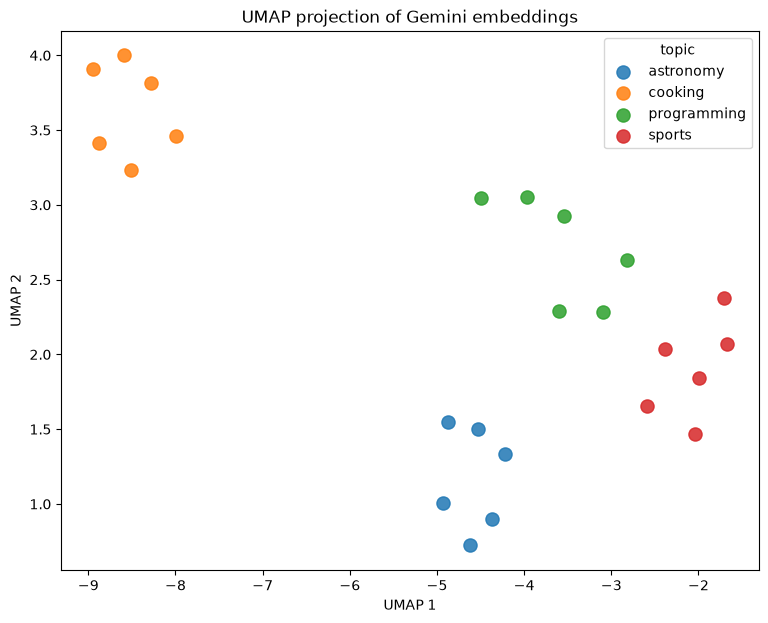

In [6]:
vectors = embed(texts)
print("shape:", vectors.shape)

coords = reduce(vectors)
plot(coords, labels)
plt.show()

---
## 7. Parameters change the story

Same vectors, four values of `n_neighbors`. Nothing about the data changed — only
what counts as a neighbour.

/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


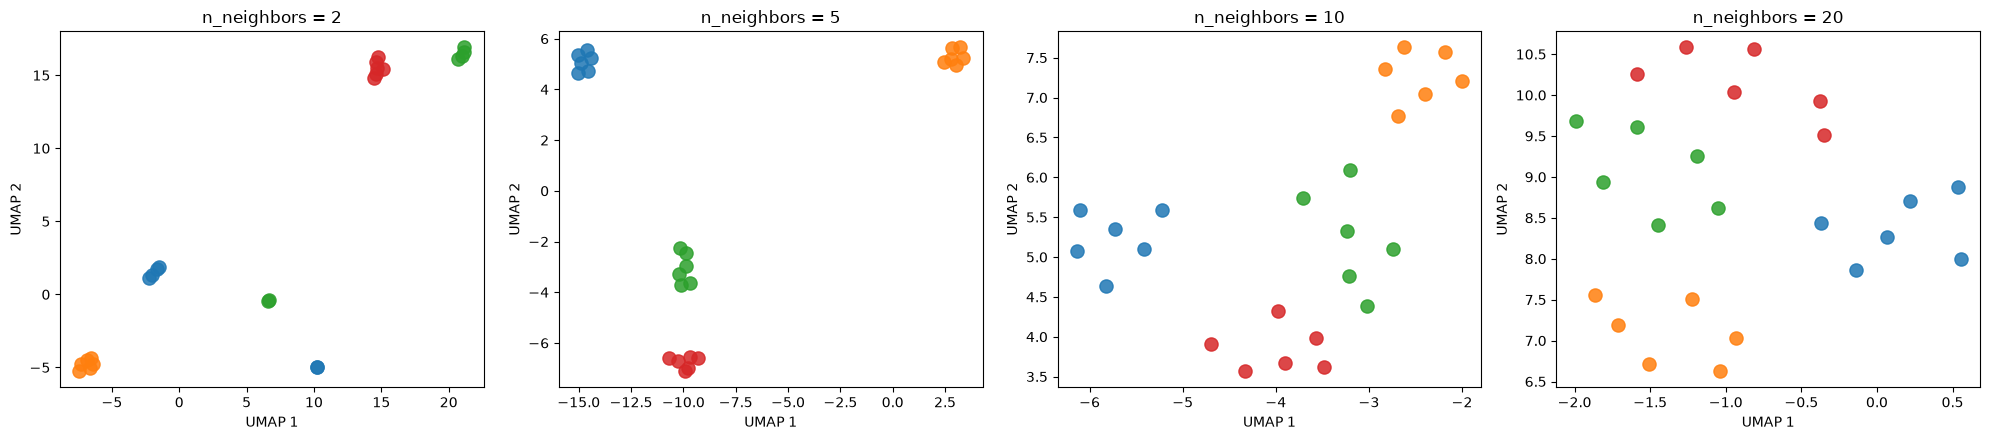

In [7]:
_, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, n in zip(axes, [2, 5, 10, 20]):
    plot(reduce(vectors, n_neighbors=n), labels, title=f"n_neighbors = {n}", ax=ax)
    ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


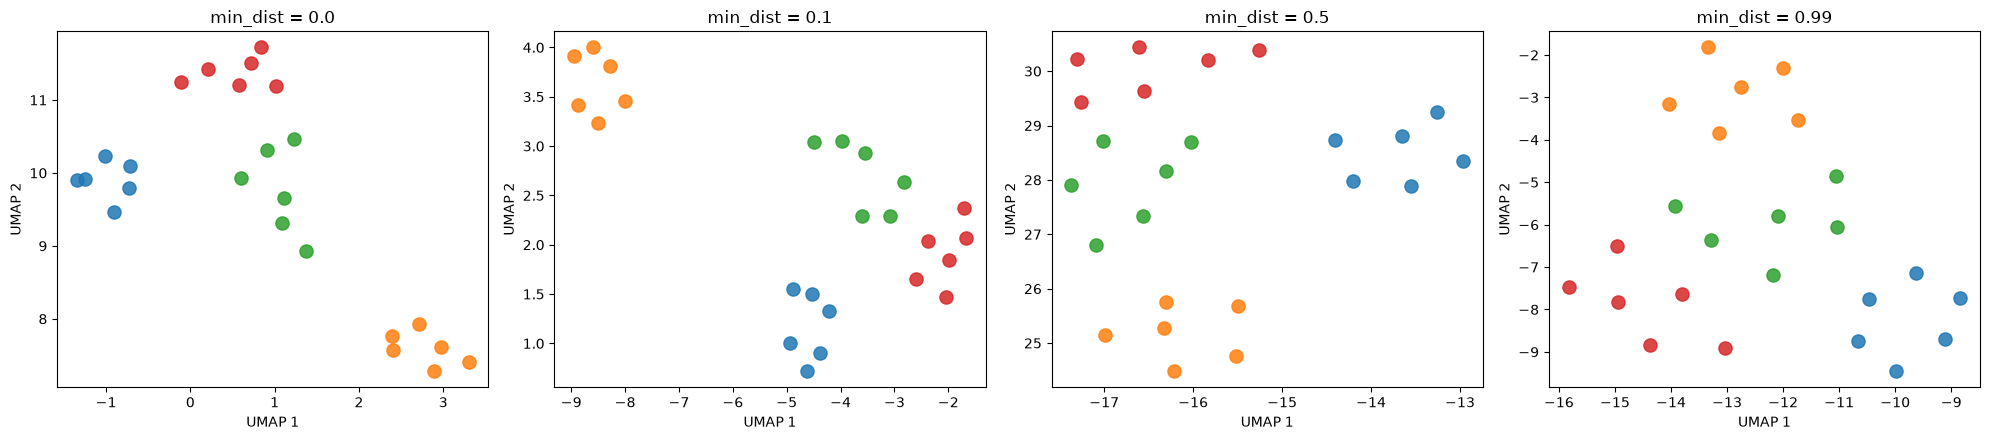

In [8]:
_, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, d in zip(axes, [0.0, 0.1, 0.5, 0.99]):
    plot(reduce(vectors, min_dist=d), labels, title=f"min_dist = {d}", ax=ax)
    ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. Is the structure real?

UMAP can invent clusters. Check the similarity in the *original* 768-D space —
bright blocks on the diagonal mean the topics were already separated before UMAP
touched anything.

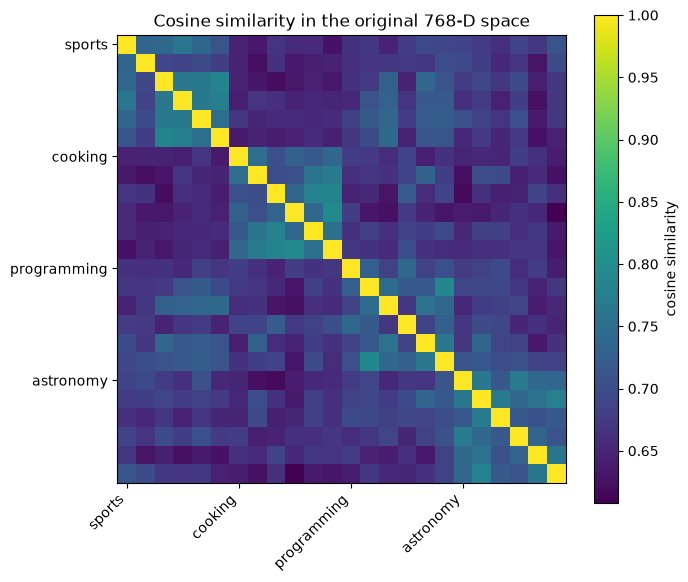

In [9]:
similarity = vectors @ vectors.T

plt.figure(figsize=(7, 6))
plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.xticks(range(0, 24, 6), sorted(set(labels), key=labels.index), rotation=45, ha="right")
plt.yticks(range(0, 24, 6), sorted(set(labels), key=labels.index))
plt.title("Cosine similarity in the original 768-D space")
plt.tight_layout()
plt.show()

In [10]:
same = np.array(labels)[:, None] == np.array(labels)[None, :]
off_diagonal = ~np.eye(len(labels), dtype=bool)

intra = similarity[same & off_diagonal].mean()
inter = similarity[~same].mean()

print(f"mean within topic : {intra:.4f}")
print(f"mean across topics: {inter:.4f}")
print(f"separation        : {intra - inter:+.4f}")

mean within topic : 0.7363
mean across topics: 0.6683
separation        : +0.0679


---
## 10. Query the space

Embed a new sentence, find its nearest neighbours, and drop it on the map.

Note `reducer.transform()` — the query joins the *existing* layout. Refitting with
the query included would move every other point.

In [12]:
query = "The goalkeeper made a diving save in extra time."
query_vector = embed([query])

scores = vectors @ query_vector[0]
for i in np.argsort(-scores)[:5]:
    print(f"{scores[i]:.3f}  [{labels[i]:<11}] {texts[i]}")

0.789  [sports     ] The striker scored a hat-trick in the second half.
0.782  [sports     ] The team lost the final on a penalty shootout.
0.727  [sports     ] He was substituted after pulling a hamstring.
0.718  [sports     ] The umpire declared the batsman out on review.
0.711  [sports     ] She broke the national record in the 200 metre sprint.


/home/vishal/Classroom/MTech-NLP/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


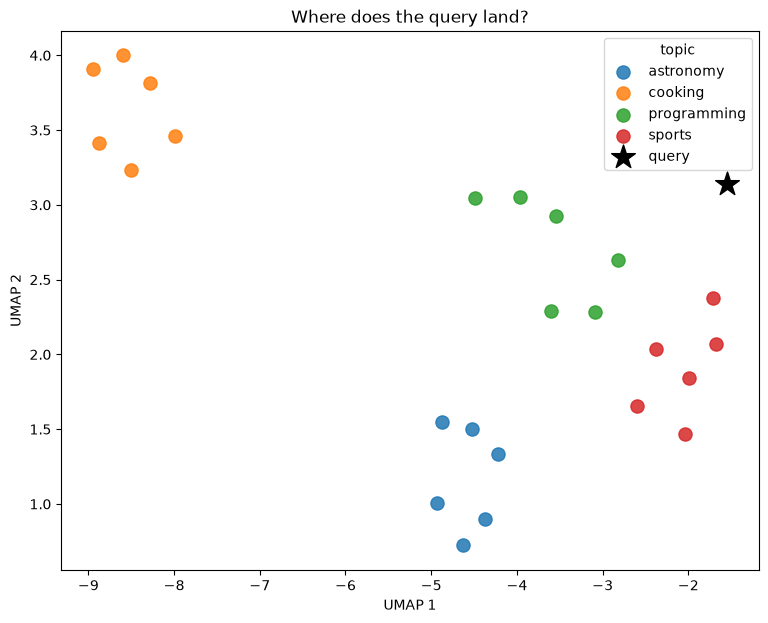

In [13]:
reducer = umap.UMAP(n_components=2, n_neighbors=8, min_dist=0.1,
                    metric="cosine", random_state=42).fit(vectors)

ax = plot(reducer.embedding_, labels, title="Where does the query land?")
query_coords = reducer.transform(query_vector)
ax.scatter(query_coords[:, 0], query_coords[:, 1],
           s=320, marker="*", color="black", zorder=5, label="query")
ax.legend(title="topic")
plt.show()